<a href="https://colab.research.google.com/github/hjfuentes/Laboratorio-Datos-Sociales/blob/main/Trading-Algoritmico/02-Modelado-y-ML/S01_libro_de_ordenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 1 — El libro de órdenes: cómo se forma realmente un precio



---

## Lo que te vas a llevar de hoy

Una sola idea, pero que cambia cómo miras todo lo demás del curso:

> ### No existe "el precio".
> ### Existe un **bid**, un **ask**, y una **cola de gente esperando**.

Todo lo que has visto llamado "precio de cierre" es un resumen de algo mucho más
complicado. Y casi todo lo que sale mal en un backtest sale mal por olvidar eso.

---

## Cómo trabajamos con los datos en esta carpeta

**Esta carpeta es autónoma.** Todo lo que necesitas está en `data/`

| Dato | Fuente | ¿Real o simulado? |
|---|---|---|
| Precios de 9 acciones (una por sector) | Tu histórico de OHLCV, resampleado a diario | ✅ Real |
| Libro de órdenes (20 niveles) | Kraken, API pública, BTC/USD | ✅ Real — capturado el 25-ago-2026 |
| Cinta de operaciones (300 trades) | Coinbase Exchange, API pública, BTC-USD | ✅ Real — capturado el 21-ago-2026 |

No hay orden de mercado sintética ni libro artificial en esta sesión. Cuando
el tema fue "cómo se forma un precio", nos pareció importante mostrar el dato
de verdad, con sus asimetrías, su ruido y sus tamaños raros incluidos.

**¿Por qué cripto para el libro y no una acción?** Porque son los únicos
mercados que publican profundidad completa del libro **gratis y sin cuenta**.
El comportamiento — colas de precio-tiempo, maker/taker, impacto — es el mismo
en cualquier mercado con libro central de órdenes.

**¿Por qué el libro está "congelado" y no en vivo?** Porque el material se
envía con antelación y tiene que funcionar sin depender de que el aula tenga
internet ese día. Al final de la sesión hay una celda opcional que muestra
cómo refrescarlo si quieres verlo moverse en vivo.

---

## Agenda

| Bloque | Tiempo | Tema |
|---|---|---|
| 1 | 15 min | La pregunta trampa: el mid price es una ilusión óptica |
| 2 | 25 min | Anatomía del libro + los **tres** spreads |
| 3 | 10 min | Cómo se capturó este libro (y cómo refrescarlo) |
| 4 | 20 min | Tipos de órdenes: la limit order como opción sin prima |
| 5 | 30 min | ¿A qué precio te llenas? + ley de raíz cuadrada y capacidad |
| 6 | 10 min | Liquidez ≠ volumen — con 9 acciones reales |
| 7 | 10 min | El spread como impuesto a la ignorancia |

> **Si vas apretado de tiempo:** el bloque 3 (captura del libro) se puede
> mandar como lectura previa, y la tabla de confusiones del bloque 7 se puede
> entregar impresa. Eso libera ~15 minutos sin perder ningún hilo.

In [ ]:
# @title Preparación del entorno
from pathlib import Path
import zipfile
import shutil

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/Tradestian/Modelado-Cuantitativo-y-Machine-Learning/main/datos/data%20S1.zip"
DATA = Path("data")

if not DATA.exists():
    archivo_zip = Path("data S1.zip")
    respuesta = requests.get(url)
    respuesta.raise_for_status()
    archivo_zip.write_bytes(respuesta.content)

    with zipfile.ZipFile(archivo_zip, "r") as zip_ref:
        zip_ref.extractall(".")

    shutil.move("data S1", str(DATA))
    archivo_zip.unlink(missing_ok=True)
    shutil.rmtree("Modelado-Cuantitativo-y-Machine-Learning", ignore_errors=True)

pd.set_option("display.width", 120)
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

equities = pd.read_parquet(DATA / "equities_reales_diario.parquet")
libro_raw = pd.read_parquet(DATA / "order_book_real_xbtusd.parquet")
trades = pd.read_parquet(DATA / "trades_reales_btcusd.parquet")
ticker_ref = pd.read_parquet(DATA / "ticker_real_btcusd.parquet")

print("✔ Entorno listo — todo local, nada de red requerida")
print(f"Acciones : {equities["ticker"].nunique()} tickers, "
      f"{equities["date"].min().date()} → {equities["date"].max().date()}")
print(f"Libro    : {len(libro_raw)} niveles reales (Kraken, XBT/USD)")
print(f"Trades   : {len(trades)} operaciones reales (Coinbase, BTC-USD), "
      f"{trades["time"].min()} → {trades["time"].max()}")


✔ Entorno listo — todo local, nada de red requerida
Acciones : 9 tickers, 2020-01-02 → 2026-06-12
Libro    : 40 niveles reales (Kraken, XBT/USD)
Trades   : 300 operaciones reales (Coinbase, BTC-USD), 2026-08-21 09:42:50.989350+00:00 → 2026-08-21 09:43:23.075549+00:00


---
# 1 · La pregunta trampa
**⏱ 10 minutos**

Empecemos por lo que ya conoces: una serie de precios de cierre. Ésta es
real — Utilities, un sector que casi nunca hace ruido.

In [ ]:
# DATOS LOCALES — reales
dte = equities[equities.ticker == "DTE"].set_index("date").sort_index()
print(dte.tail(15)[["open", "high", "low", "close", "volume"]].round(2))

ultimo = dte.iloc[-1]
print(f"""
DTE (DTE Energy, utilities) — precio de cierre del último día: {ultimo['close']:.2f}
""")

              open    high     low   close     volume
date                                                 
2026-02-20  146.08  146.12  143.93  145.02   925151.0
2026-02-23  145.59  146.50  144.86  145.85  1193806.0
2026-02-24  145.66  146.29  143.80  146.15   872878.0
2026-02-25  146.20  146.56  144.15  146.01   970448.0
2026-02-26  146.21  147.41  146.03  146.62   737814.0
2026-02-27  146.77  148.40  146.00  148.22   777867.0
2026-03-02  147.81  148.58  146.82  147.59   807054.0
2026-03-03  145.45  149.43  144.06  148.20  1295866.0
2026-03-04  147.33  150.16  146.88  150.10  1433745.0
2026-03-05  148.48  149.73  148.15  148.65  1396114.0
2026-03-06  147.90  150.31  146.71  150.11  1250676.0
2026-03-09  150.44  150.74  147.18  148.99   692951.0
2026-03-10  148.41  149.51  147.61  147.81   567487.0
2026-03-11  147.58  147.79  146.10  146.56   683093.0
2026-03-12  146.86  149.51  145.54  147.60   827823.0

DTE (DTE Energy, utilities) — precio de cierre del último día: 147.60



### 🙋 Pregunta para la clase

**Si yo hubiera querido comprar 10.000 acciones de DTE ese día, ¿habría pagado
ese precio?**

*(Dejen que respondan antes de seguir.)*

La respuesta corta es **no**. La respuesta larga es esta sesión entera.

Ese número de "cierre" es el precio de **la última transacción**. No dice:

- a qué precio podías **comprar** en ese momento
- a qué precio podías **vender**
- **cuánto** podías comprar o vender a ese precio

Y esas tres preguntas son las que de verdad importan para operar.

### 🧠 El mid price es una ilusión óptica

Éste es el reencuadre del que depende todo el resto de la Fase 2 y la Fase 3.
Vale la pena decirlo despacio:

> **No existe "el precio". Existe un bid, un ask, y una cola de gente
> esperando. Todo lo que llamas "retorno" en un backtest es una ficción
> construida sobre una serie de precios inexacta.**

El **mid price** — el promedio entre bid y ask — es el ejemplo más puro. Es el
número que usan todos los gráficos, todos los backtests y todas las APIs. Y es
un precio al que **literalmente nadie transa**. Es una construcción
matemática, no un lugar donde puedas poner dinero.

Cuando tu backtest calcula un retorno del 2%, está midiendo el movimiento de
una serie de ilusiones ópticas. La pregunta que hay que hacerse siempre es:
*¿cuánto de ese 2% habría sobrevivido al pasar por el libro de órdenes?*

**Y la microestructura no es un tecnicismo de plomería.** Es comportamiento
humano y costo de la información, cristalizados en una estructura de datos.
Cada nivel del libro es alguien que decidió cuánto está dispuesto a pagar por
tener razón antes que los demás.

---
# 2 · Anatomía de un libro de órdenes real
**⏱ 20 minutos**

El **libro de órdenes** (*order book*, LOB) es simplemente dos colas:

- **BID**: gente que quiere COMPRAR, ordenada de mayor a menor precio
- **ASK**: gente que quiere VENDER, ordenada de menor a mayor precio

La regla que ordena la cola se llama **prioridad precio-tiempo**:

> Mejor precio primero. A igual precio, quien llegó antes.

Lo que sigue **no es un ejemplo de libro de texto**. Es el libro real de
BTC/USD en Kraken, capturado por API pública el 25 de agosto de 2026.

In [ ]:
# DATOS LOCALES — reales, Kraken XBT/USD
bids = (libro_raw[libro_raw.lado == "bid"]
        .sort_values("nivel")[["precio", "tamano_btc"]]
        .rename(columns={"precio": "bid_price", "tamano_btc": "bid_size"})
        .reset_index(drop=True))
asks = (libro_raw[libro_raw.lado == "ask"]
        .sort_values("nivel")[["precio", "tamano_btc"]]
        .rename(columns={"precio": "ask_price", "tamano_btc": "ask_size"})
        .reset_index(drop=True))
libro = pd.concat([bids, asks], axis=1)
print(libro.to_string(index=False))

 bid_price  bid_size  ask_price  ask_size
   78765.2     0.028    78765.3     3.314
   78763.9     0.001    78765.6     0.370
   78763.4     0.006    78765.7     0.635
   78759.9     0.001    78765.8     0.032
   78759.0     0.001    78766.1     0.006
   78758.8     0.001    78766.4     0.004
   78758.6     0.635    78767.5     0.017
   78756.7     0.046    78767.7     0.001
   78756.6     0.635    78768.0     0.012
   78756.0     0.001    78768.3     0.635
   78752.8     0.001    78768.9     0.040
   78752.3     0.635    78769.0     0.134
   78752.1     0.001    78771.6     0.001
   78751.0     0.001    78773.0     0.637
   78749.4     0.076    78773.2     0.169
   78747.2     0.020    78773.8     0.001
   78747.1     0.064    78774.0     0.635
   78747.0     0.002    78774.1     0.667
   78746.5     0.001    78774.7     0.060
   78744.2     0.012    78775.5     0.001


In [ ]:
libro_raw

,lado,nivel,precio,tamano_btc,ts_orden,capturado_en
0,bid,1,78765.2,0.028,1787720704,2026-08-26 05:08:59+00:00
1,bid,2,78763.9,0.001,1787720695,2026-08-26 05:08:59+00:00
2,bid,3,78763.4,0.006,1787720702,2026-08-26 05:08:59+00:00
3,bid,4,78759.9,0.001,1787720690,2026-08-26 05:08:59+00:00
4,bid,5,78759.0,0.001,1787720668,2026-08-26 05:08:59+00:00
5,bid,6,78758.8,0.001,1787720703,2026-08-26 05:08:59+00:00
6,bid,7,78758.6,0.635,1787720707,2026-08-26 05:08:59+00:00
7,bid,8,78756.7,0.046,1787720707,2026-08-26 05:08:59+00:00
8,bid,9,78756.6,0.635,1787720707,2026-08-26 05:08:59+00:00
9,bid,10,78756.0,0.001,1787720703,2026-08-26 05:08:59+00:00


In [ ]:
mejor_bid = libro["bid_price"].iloc[0]
mejor_ask = libro["ask_price"].iloc[0]
mid = (mejor_bid + mejor_ask) / 2

spread = mejor_ask - mejor_bid

print(f"""
╭──────────────────────────────────────────────────────────╮
│  MEJOR BID : {mejor_bid:10.2f}   ({libro['bid_size'].iloc[0]:.4f} BTC esperando comprar)
│  MEJOR ASK : {mejor_ask:10.2f}   ({libro['ask_size'].iloc[0]:.4f} BTC esperando vender)
│                                                          │
│  MID       : {mid:10.2f}   ← el promedio. NADIE transa aquí.
│  SPREAD    : {spread:10.2f}   =  {spread/mid*1e4:.3f} puntos básicos
╰──────────────────────────────────────────────────────────╯

Léelo así:
  - Si quieres COMPRAR YA  → pagas {mejor_ask:,.2f}
  - Si quieres VENDER YA   → recibes {mejor_bid:,.2f}
  - La diferencia, ${spread:.2f}, es el peaje por tener prisa.

Nota: {spread/mid*1e4:.3f} bps es un spread ALTÍSIMAMENTE estrecho. BTC/USD en
un exchange grande es de lo más líquido que existe en cualquier mercado del
mundo.
""")


╭──────────────────────────────────────────────────────────╮
│  MEJOR BID :   78765.20   (0.0280 BTC esperando comprar)
│  MEJOR ASK :   78765.30   (3.3140 BTC esperando vender)
│                                                          │
│  MID       :   78765.25   ← el promedio. NADIE transa aquí.
│  SPREAD    :       0.10   =  0.013 puntos básicos
╰──────────────────────────────────────────────────────────╯

Léelo así:
  - Si quieres COMPRAR YA  → pagas 78,765.30
  - Si quieres VENDER YA   → recibes 78,765.20
  - La diferencia, $0.10, es el peaje por tener prisa.

Nota: 0.013 bps es un spread ALTÍSIMAMENTE estrecho. BTC/USD en
un exchange grande es de lo más líquido que existe en cualquier mercado del
mundo.



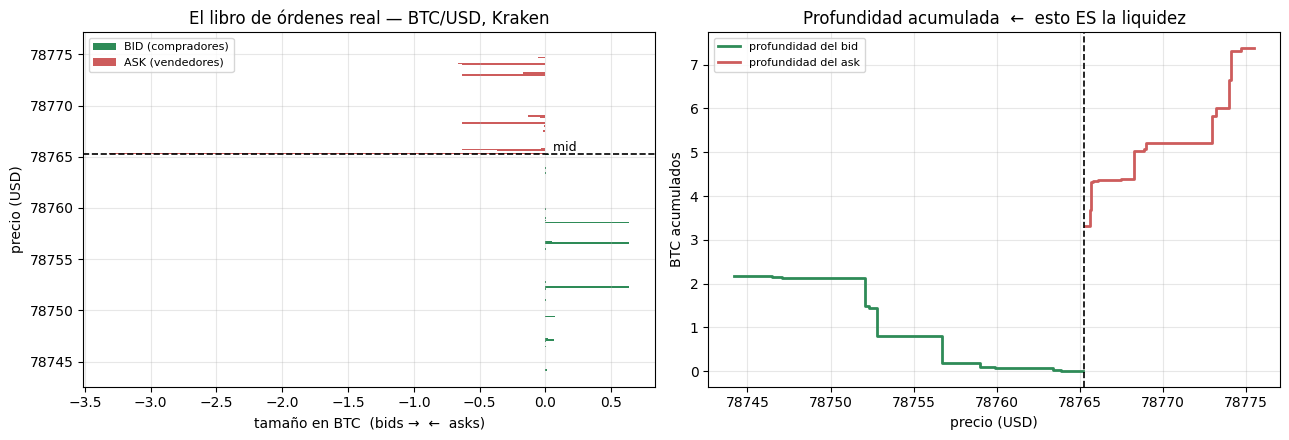

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].barh(libro["bid_price"], libro["bid_size"], height=0.15,
           color="seagreen", label="BID (compradores)")
ax[0].barh(libro["ask_price"], -libro["ask_size"], height=0.15,
           color="indianred", label="ASK (vendedores)")
ax[0].axhline(mid, ls="--", c="k", lw=1.2)
ax[0].text(0, mid, "  mid", va="bottom", fontsize=9)
ax[0].set_xlabel("tamaño en BTC  (bids →  ←  asks)")
ax[0].set_ylabel("precio (USD)")
ax[0].set_title("El libro de órdenes real — BTC/USD, Kraken")
ax[0].legend(fontsize=8)

ax[1].step(libro["bid_price"][::-1], libro["bid_size"][::-1].cumsum()[::-1],
           where="post", color="seagreen", lw=2, label="profundidad del bid")
ax[1].step(libro["ask_price"], libro["ask_size"].cumsum(),
           where="post", color="indianred", lw=2, label="profundidad del ask")
ax[1].axvline(mid, ls="--", c="k", lw=1.2)
ax[1].set_xlabel("precio (USD)")
ax[1].set_ylabel("BTC acumulados")
ax[1].set_title("Profundidad acumulada  ←  esto ES la liquidez")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 📌 Lo que hay que ver en el gráfico de la derecha

Esa curva responde la pregunta: **"si quiero comprar X BTC, ¿hasta qué precio
tengo que subir?"**

Cuanto más **plana** es la curva, más líquido es el activo: puedes mover mucho
tamaño sin mover el precio. Cuanto más **empinada**, más caro te sale ser
grande. Fíjate que estos 20 niveles solo cubren unos **pocos BTC** por lado —
el libro visible es más angosto de lo que uno imagina para el activo más
líquido del mercado cripto.

Guarda esa imagen mental. En el bloque 5 la vamos a usar con números.

### 🧠 Hay tres spreads distintos, y confundirlos cuesta dinero

Cuando alguien dice "el spread", casi siempre se refiere al primero de estos
tres. Los otros dos son los que de verdad describen lo que te pasó.

**1 · Spread cotizado** — lo que ves en pantalla:

$$s_t = P^{ask}_t - P^{bid}_t \qquad\text{o en relativo}\qquad \frac{s_t}{m_t},\quad m_t=\frac{P^{ask}_t+P^{bid}_t}{2}$$

Ese ultimo termino relativo,conocido como 'Half spread percentage', es el costo porcentual de transacción para entrar o salir de un posición en ese momento.

**2 · Spread efectivo** — lo que **realmente pagaste**:

$$\text{efectivo} = 2\,|P_t - m_t|$$

donde $P_t$ es tu precio de ejecución. Puede ser **menor** que el cotizado (si
hubo *price improvement*, alguien te dio un precio mejor que el visible) o
**mucho mayor** (si barriste el libro). Ésta es
la métrica que importa.

**3 · Spread realizado** — lo que el market maker **se quedó**:

$$\text{realizado} = 2\, D_t\,(P_t - m_{t+\Delta})$$

con $D_t=+1$ si compraste, $-1$ si vendiste, y $\Delta$ típicamente 5 minutos.
Mide cuánto ganó el que te vendió, *después* de que el precio se movió.

### 🔑 La descomposición que vale la pena entender

$$\boxed{\;\text{Spread efectivo} \;=\; \text{Spread realizado} \;+\; \text{Impacto permanente}\;}$$

Leído en castellano:

> **Lo que tú pagas = lo que el market maker gana + lo que el mercado aprendió
> de tu orden.**

Esa segunda pieza es la interesante. Cuando compras, el precio sube un poco y
**se queda arriba**. Parte de tu costo no fue una fricción que alguien se
embolsó: fue el mercado actualizando su creencia sobre cuánto vale el activo,
porque tu orden le dio información.

**🙋 La pregunta para la clase:** *si el mercado aprende de tus órdenes, ¿qué
le estás enseñando cada vez que operas?*

Ahí está el germen de por qué existen las órdenes iceberg, por qué los fondos
grandes parten sus órdenes, y por qué revelar tamaño es caro. Volvemos a esto
en la sesión 2.

In [ ]:
### Simualción de los tres tipos de spread: cotizado, efectivo y realizado

np.random.seed(42)          # Para resultados reproducibles
N = 100                     # Total de pasos de tiempo (ej. minutos)
volatilidad = 0.01
precio_inicial = 100.0
spread_cotizado = 0.80      # Diferencia fija entre Ask y Bid
half_spread = spread_cotizado / 2.0

# Generamos el precio medio (Mid) como un paseo aleatorio ( Random Walk )
returns = np.random.normal(0, volatilidad, N)
mid = precio_inicial * np.exp(np.cumsum(returns))
mid = np.insert(mid, 0, precio_inicial)   # Array de 101 elementos

# Calculamos Bid y Ask
bid = mid - half_spread
ask = mid + half_spread


t = 50                     # Momento de la ejecución,digamos que neustra latencia nos permite ejecuatr en 50ms
delta = 5                  # ms después para el spread realizado
t_delta = min(t + delta, N)

D_t = 1                    # +1 = Compra, -1 = Venta

# Tres escenarios de precio de ejecución (P_t)
P_t_A = ask[t]                     # Escenario 1: Ejecución al Ask (normal)
P_t_B = ask[t] - 0.05              # Escenario 2: Price improvement (mejor precio)
P_t_C = ask[t] + 0.10              # Escenario 3: Impacto (barres el libro)

# Almacenamos en un diccionario para iterar
escenarios = {
    "Sin mejora (al Ask)": P_t_A,
    "Con Price Improvement": P_t_B,
    "Con Impacto de Mercado": P_t_C
}


def calc_quoted(bid, ask, mid):
    """Spread cotizado absoluto y relativo (half spread %)"""
    s_abs = ask - bid
    s_rel = s_abs / mid
    return s_abs, s_rel

def calc_effective(P_t, mid_t):
    """Spread efectivo: 2 * |P_t - m_t|"""
    return 2.0 * abs(P_t - mid_t)

def calc_realized(P_t, mid_delta, D_t):
    """Spread realizado: 2 * D_t * (P_t - m_{t+delta})"""
    return 2.0 * D_t * (P_t - mid_delta)

# Calculamos el cotizado (es constante en este ejemplo)
s_abs, s_rel = calc_quoted(bid[t], ask[t], mid[t])

# Guardamos resultados en un DataFrame
resultados = []
for nombre, P_t in escenarios.items():
    eff = calc_effective(P_t, mid[t])
    real = calc_realized(P_t, mid[t_delta], D_t)
    resultados.append({
        "Caso": nombre,
        "P_t (ejecución)": P_t,
        "Cotizado (abs)": s_abs,
        "Cotizado (rel %)": s_rel * 100,
        "Efectivo": eff,
        "Realizado": real
    })
df = pd.DataFrame(resultados)


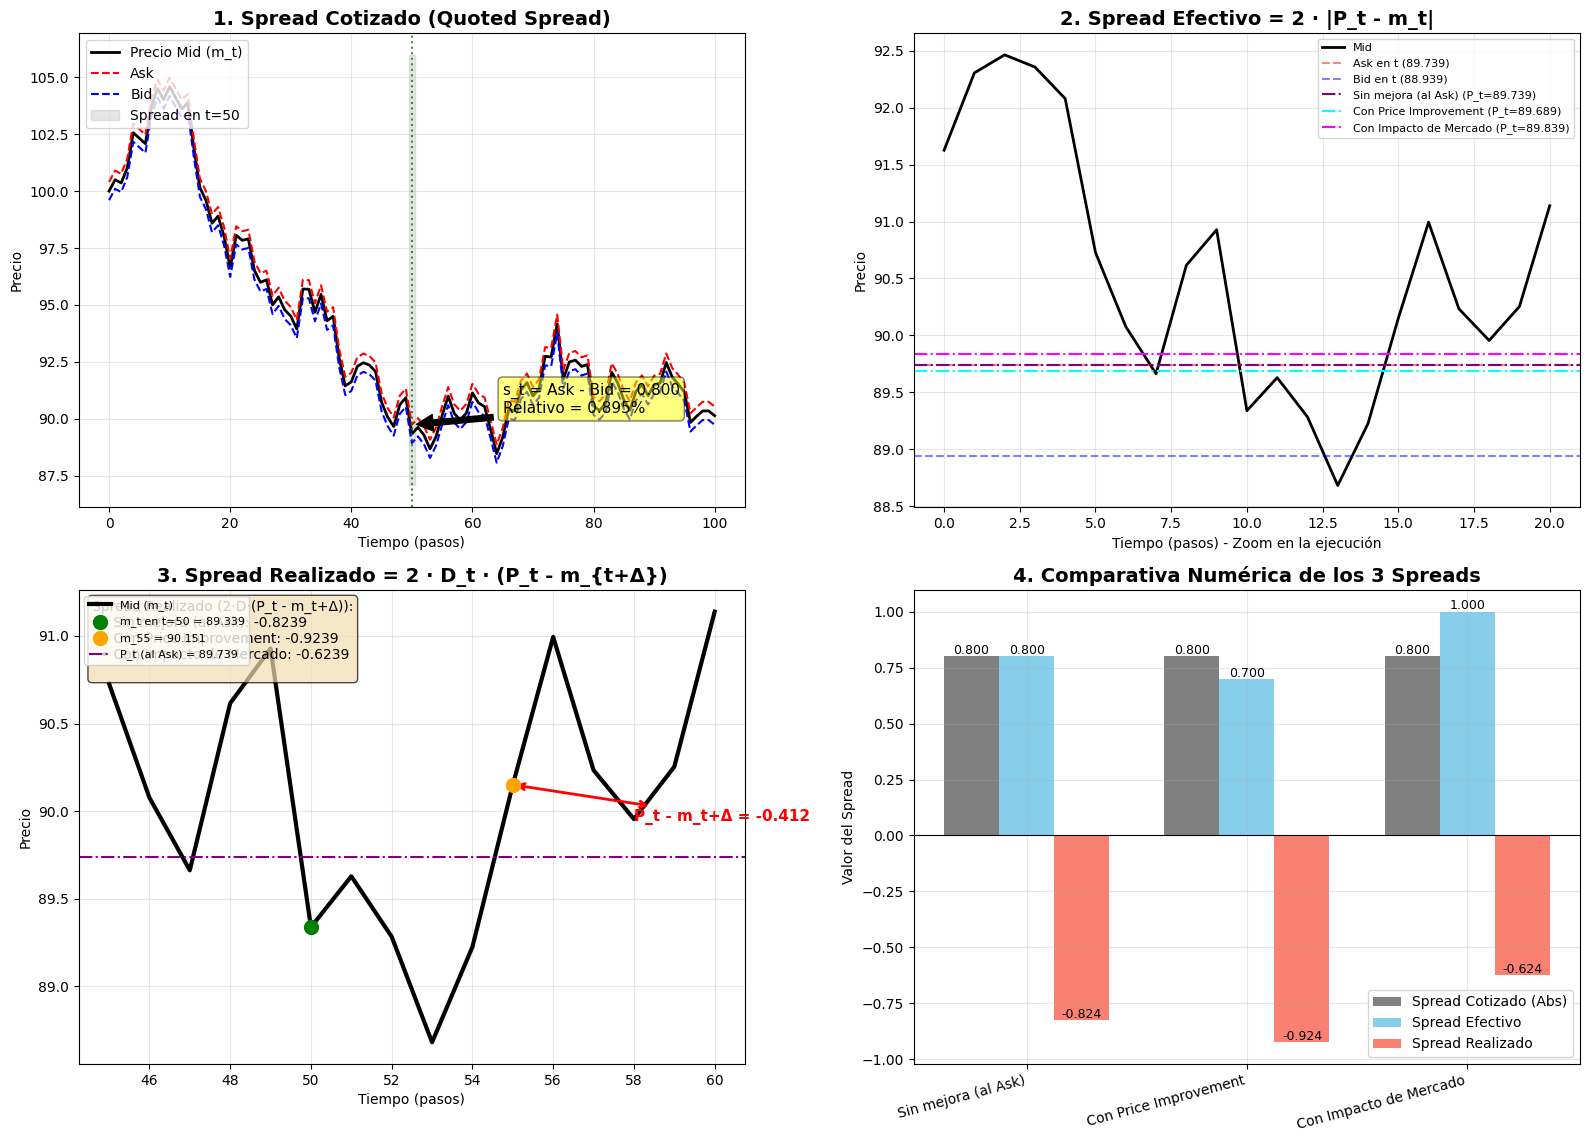


RESUMEN DE RESULTADOS PARA CADA ESCENARIO
                  Caso  P_t (ejecución)  Cotizado (abs)  Cotizado (rel %)  Efectivo  Realizado
   Sin mejora (al Ask)          89.7386             0.8            0.8955       0.8    -0.8239
 Con Price Improvement          89.6886             0.8            0.8955       0.7    -0.9239
Con Impacto de Mercado          89.8386             0.8            0.8955       1.0    -0.6239

INTERPRETACIÓN PASO A PASO:

▶ SPREAD COTIZADO (Gráfico 1):
   Es simplemente la distancia Ask - Bid. En este ejemplo es fijo (0.800).
   Es el costo de entrada/salida que ves en la pantalla ANTES de operar.

▶ SPREAD EFECTIVO (Gráfico 2):
   Mide la distancia de tu ejecución (P_t) respecto al Mid (m_t).
   - Si te dan 'Price Improvement' (cyan), el Efectivo es MENOR que el Cotizado.
   - Si barres el libro (magenta), el Efectivo es MAYOR (pagas más caro).

▶ SPREAD REALIZADO (Gráfico 3):
   Mide cuánto gana el Market Maker tras el movimiento del precio Δ=5 minutos.
   

In [ ]:
#### SPREAD COTIZADO

fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(2, 2, 1)
ax1.plot(mid, color='black', linewidth=2, label='Precio Mid (m_t)')
ax1.plot(ask, color='red', linestyle='--', linewidth=1.5, label='Ask')
ax1.plot(bid, color='blue', linestyle='--', linewidth=1.5, label='Bid')
# Rellenamos la zona del spread en el momento t
ax1.axvline(x=t, color='green', linestyle=':', alpha=0.8)
ax1.fill_betweenx([min(bid)-1, max(ask)+1], t-0.5, t+0.5,
                  color='gray', alpha=0.2, label=f'Spread en t={t}')
# Anotación de la fórmula
ax1.annotate(f's_t = Ask - Bid = {s_abs:.3f}\nRelativo = {s_rel:.3%}',
             xy=(t, ask[t]), xytext=(t+15, ask[t]+0.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.5))
ax1.set_title('1. Spread Cotizado (Quoted Spread)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tiempo (pasos)')
ax1.set_ylabel('Precio')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(2, 2, 2)
# Mostramos el Ask/Bid/Mid solo alrededor del momento t para enfocar
ax2.plot(mid[t-10:t+11], color='black', linewidth=2, label='Mid')
ax2.axhline(y=ask[t], color='red', linestyle='--', alpha=0.5, label=f'Ask en t ({ask[t]:.3f})')
ax2.axhline(y=bid[t], color='blue', linestyle='--', alpha=0.5, label=f'Bid en t ({bid[t]:.3f})')

# Colores para cada escenario
colores = {'Sin mejora (al Ask)': 'purple',
           'Con Price Improvement': 'cyan',
           'Con Impacto de Mercado': 'magenta'}

# Dibujamos cada precio de ejecución y su distancia al Mid
for i, (nombre, P_t) in enumerate(escenarios.items()):
    color = colores[nombre]
    # Línea horizontal del precio de ejecución
    ax2.axhline(y=P_t, color=color, linestyle='-.', linewidth=1.5,
                label=f'{nombre} (P_t={P_t:.3f})')
    # Flecha que muestra la distancia |P_t - mid|
    distancia = abs(P_t - mid[t])
    ax2.annotate(f'|P_t - m_t| = {distancia:.3f}',
                 xy=(t-10+ (i*6), (P_t + mid[t])/2),
                 xytext=(t-10+ (i*6) + 2, (P_t + mid[t])/2 + 0.1),
                 arrowprops=dict(arrowstyle='<->', color=color),
                 fontsize=9, color=color)
    # Efectivo = 2 * distancia
    eff_value = calc_effective(P_t, mid[t])


ax2.set_title('2. Spread Efectivo = 2 · |P_t - m_t|', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tiempo (pasos) - Zoom en la ejecución')
ax2.set_ylabel('Precio')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(2, 2, 3)
# Mostramos el Mid desde antes hasta después de la ejecución
inicio_zoom = max(0, t - 5)
fin_zoom = min(N, t + delta + 5)
tiempo_zoom = np.arange(inicio_zoom, fin_zoom + 1)

ax3.plot(tiempo_zoom, mid[inicio_zoom:fin_zoom+1],
         color='black', linewidth=3, label='Mid (m_t)')

# Marcamos el punto de ejecución
ax3.scatter(t, mid[t], color='green', s=100, zorder=5, label=f'm_t en t={t} = {mid[t]:.3f}')
ax3.scatter(t_delta, mid[t_delta], color='orange', s=100, zorder=5,
            label=f'm_{t+delta} = {mid[t_delta]:.3f}')

# Dibujamos el precio de ejecución del escenario 1 (el más común) para la flecha principal
P_t_principal = escenarios["Sin mejora (al Ask)"]
ax3.axhline(y=P_t_principal, color='purple', linestyle='-.',
            label=f'P_t (al Ask) = {P_t_principal:.3f}')

# Flecha que muestra el movimiento del precio (P_t - m_{t+delta})
ax3.annotate(f'P_t - m_t+Δ = {P_t_principal - mid[t_delta]:.3f}',
             xy=(t_delta, mid[t_delta]), xytext=(t_delta+3, (mid[t_delta]+P_t_principal)/2),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2),
             fontsize=11, color='red', fontweight='bold')

# Mostramos el valor del Realizado para los 3 escenarios en un recuadro
texto_realizado = "Spread Realizado (2·D·(P_t - m_t+Δ)):\n"
for nombre, P_t in escenarios.items():
    real_val = calc_realized(P_t, mid[t_delta], D_t)
    texto_realizado += f"  • {nombre}: {real_val:.4f}\n"
ax3.text(0.02, 0.98, texto_realizado, transform=ax3.transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.7))

ax3.set_title('3. Spread Realizado = 2 · D_t · (P_t - m_{t+Δ})', fontsize=14, fontweight='bold')
ax3.set_xlabel('Tiempo (pasos)')
ax3.set_ylabel('Precio')
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)


ax4 = plt.subplot(2, 2, 4)
categorias = df["Caso"].tolist()
cotizados = [s_abs] * 3
efectivos = df["Efectivo"].tolist()
realizados = df["Realizado"].tolist()

x = np.arange(len(categorias))  # Posiciones
width = 0.25  # Ancho de las barras

ax4.bar(x - width, cotizados, width, label='Spread Cotizado (Abs)', color='gray')
ax4.bar(x, efectivos, width, label='Spread Efectivo', color='skyblue')
ax4.bar(x + width, realizados, width, label='Spread Realizado', color='salmon')

# Añadir valores encima de las barras
for i, v in enumerate(cotizados):
    ax4.text(i - width, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(efectivos):
    ax4.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(realizados):
    ax4.text(i + width, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

ax4.set_xticks(x)
ax4.set_xticklabels(categorias, rotation=15, ha='right')
ax4.set_ylabel('Valor del Spread')
ax4.set_title('4. Comparativa Numérica de los 3 Spreads', fontsize=14, fontweight='bold')
ax4.axhline(0, color='black', linewidth=0.8)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Ajustamos el layout para que no se solape
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Deja espacio para el título global
plt.show()

# =============================================================================
# 5. IMPRESIÓN EN CONSOLA (Paso a paso)
# =============================================================================
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS PARA CADA ESCENARIO")
print("="*70)
print(df.to_string(index=False))
print("\n" + "="*70)
print("INTERPRETACIÓN PASO A PASO:")
print("="*70)
print("""
▶ SPREAD COTIZADO (Gráfico 1):
   Es simplemente la distancia Ask - Bid. En este ejemplo es fijo ({:.3f}).
   Es el costo de entrada/salida que ves en la pantalla ANTES de operar.

▶ SPREAD EFECTIVO (Gráfico 2):
   Mide la distancia de tu ejecución (P_t) respecto al Mid (m_t).
   - Si te dan 'Price Improvement' (cyan), el Efectivo es MENOR que el Cotizado.
   - Si barres el libro (magenta), el Efectivo es MAYOR (pagas más caro).

▶ SPREAD REALIZADO (Gráfico 3):
   Mide cuánto gana el Market Maker tras el movimiento del precio Δ={} minutos.
   Para una COMPRA (D=+1):
   - Si el precio BAJA después (m_t+Δ < P_t) → Realizado POSITIVO (MM gana).
   - Si el precio SUBE después (m_t+Δ > P_t) → Realizado NEGATIVO (MM pierde).
   Fíjate que en el escenario con Impacto, el MM gana mucho porque te vendió muy caro.
""".format(s_abs, delta))

---
# 3 · Cómo se capturó este libro (y cómo refrescarlo)
**⏱ 15 minutos**

Este libro no es un ejemplo inventado: es una foto real, tomada una sola vez,
de la API pública de Kraken. No necesitas cuenta, API key, ni pagar nada.

```
GET https://api.kraken.com/0/public/Depth?pair=XBTUSD&count=20
```

La función de abajo es la que usamos para capturar el archivo que acabas de
leer. **No hace falta ejecutarla en clase** — está aquí para que veas
exactamente de dónde salió el dato, y para que la puedas correr tú si tienes
internet y quieres ver el libro moverse de verdad.

In [ ]:
# 🌐 OPCIONAL — solo si quieres refrescar el libro con internet real
def traer_libro_en_vivo(par="XBTUSD", niveles=20):
    """
    Descarga un snapshot real del libro de Kraken. Requiere `pip install
    requests` y una conexión a internet real (no funciona en un sandbox
    aislado). Devuelve (DataFrame, fuente).
    """
    import requests
    try:
        r = requests.get(
            "https://api.kraken.com/0/public/Depth",
            params={"pair": par, "count": niveles}, timeout=5,
        )
        r.raise_for_status()
        data = r.json()
        clave = list(data["result"].keys())[0]
        libro_api = data["result"][clave]
        df = pd.DataFrame({
            "bid_price": [float(x[0]) for x in libro_api["bids"]],
            "bid_size":  [float(x[1]) for x in libro_api["bids"]],
            "ask_price": [float(x[0]) for x in libro_api["asks"]],
            "ask_size":  [float(x[1]) for x in libro_api["asks"]],
        })
        return df, "🌐 EN VIVO — Kraken"
    except Exception as e:
        return libro, f"📦 LOCAL (la API no respondió: {type(e).__name__})"


# print("Descomenta para probar con tu propio internet:")
# libro_vivo, fuente = traer_libro_en_vivo()
# print(f"Fuente: {fuente}\n")
# print(libro_vivo.head(8).to_string(index=False))

print("""
Si corres traer_libro_en_vivo() varias veces seguidas vas a ver que:

1. Los TAMAÑOS cambian cada vez. Gente entrando y cancelando órdenes.
2. El SPREAD se abre y se cierra.
3. A veces el mejor precio DESAPARECE entre una consulta y la siguiente.

Y aquí está la pregunta incómoda: si el libro cambia varias veces por segundo,
¿qué significa exactamente "el precio de cierre de las 4 de la tarde"?

Significa: la última transacción que ocurrió antes de las 4. Ni más ni menos.
Es un punto arbitrario de una película que nunca para.
""")


Si corres traer_libro_en_vivo() varias veces seguidas vas a ver que:

1. Los TAMAÑOS cambian cada vez. Gente entrando y cancelando órdenes.
2. El SPREAD se abre y se cierra.
3. A veces el mejor precio DESAPARECE entre una consulta y la siguiente.

Y aquí está la pregunta incómoda: si el libro cambia varias veces por segundo,
¿qué significa exactamente "el precio de cierre de las 4 de la tarde"?

Significa: la última transacción que ocurrió antes de las 4. Ni más ni menos.
Es un punto arbitrario de una película que nunca para.



In [ ]:
traer_libro_en_vivo()

(    bid_price  bid_size  ask_price  ask_size
 0     86691.5     0.635    86691.6     1.265
 1     86689.5     0.003    86692.3     0.001
 2     86689.4     2.884    86692.4     0.174
 3     86688.0     0.001    86692.5     2.023
 4     86687.4     0.001    86693.7     0.065
 5     86686.5     0.001    86694.0     2.884
 6     86686.3     0.001    86696.1     0.098
 7     86685.8     0.001    86696.2     2.884
 8     86685.2     0.001    86696.6     0.890
 9     86685.1     2.884    86697.4     0.024
 10    86684.0     0.098    86698.2     0.058
 11    86683.9     0.554    86699.0     2.884
 12    86683.7     0.001    86700.9     0.001
 13    86681.3     0.001    86703.6     0.160
 14    86680.2     0.001    86703.7     0.098
 15    86680.0     0.001    86704.0     0.436
 16    86679.8     2.885    86705.2     0.001
 17    86679.4     0.001    86705.9     0.012
 18    86679.3     0.035    86706.0     0.002
 19    86679.2     0.024    86706.2     0.021,
 '🌐 EN VIVO — Kraken')

### 🙋 Para hacer en vivo con la clase (si hay internet)

Ejecuten `traer_libro_en_vivo()` tres o cuatro veces seguidas y comparen los
tamaños y el spread contra la foto congelada de arriba.

---
# 4 · Tipos de órdenes
**⏱ 20 minutos**

Toda orden responde a una pregunta: **¿qué sacrificas, precio o certeza?**

### Las dos órdenes fundamentales

| | **MARKET** | **LIMIT** |
|---|---|---|
| Qué pides | "Ejecuta YA, al precio que sea" | "Ejecuta a este precio o mejor" |
| Qué garantiza | ✅ Ejecución | ✅ Precio |
| Qué NO garantiza | ❌ Precio | ❌ Ejecución |
| Efecto en el libro | **Consume** liquidez (la quita) | **Provee** liquidez (la añade) |
| Cómo te llaman | **taker** | **maker** |
| Comisión | La más alta | La más baja — a veces te **pagan** |

**Por qué los exchanges pagan a los makers:** sin órdenes limit el libro estaría
vacío y nadie podría operar. Le pagan a quien pone el mostrador.

### Un dato real que confirma la teoría

La cinta de operaciones que cargamos (300 trades reales, BTC-USD, Coinbase)
trae el lado (`buy`/`sell`) de cada operación. Mira los tamaños:

In [ ]:
print(trades[["time", "side", "price", "size"]].sample(10, random_state=3)
      .sort_values("time").to_string(index=False))

print(f"""
Fíjate en la dispersión de tamaños: hay operaciones de 0.00000001 BTC
(polvo — probablemente bots reequilibrando) junto a operaciones de 0.10 o
0.17 BTC (varios miles de dólares, probablemente una persona o un algoritmo
más grande). En un mercado real conviven órdenes de tamaños completamente
distintos, todo el tiempo, en la misma cinta.
""")

                            time side    price       size
2026-08-21 09:42:52.992975+00:00 sell 78042.49 1.0827e-04
2026-08-21 09:42:55.453178+00:00  buy 78028.56 4.0000e-08
2026-08-21 09:43:02.407116+00:00 sell 78037.74 6.0832e-04
2026-08-21 09:43:08.692737+00:00 sell 78066.84 1.5000e-05
2026-08-21 09:43:10.525746+00:00  buy 78101.80 1.0000e-01
2026-08-21 09:43:14.376706+00:00  buy 78112.06 8.0520e-05
2026-08-21 09:43:15.255865+00:00 sell 78112.07 1.0552e-02
2026-08-21 09:43:15.358663+00:00 sell 78119.04 1.5000e-05
2026-08-21 09:43:18.356125+00:00  buy 78126.24 5.1279e-03
2026-08-21 09:43:21.759298+00:00  buy 78139.47 1.7000e-07

Fíjate en la dispersión de tamaños: hay operaciones de 0.00000001 BTC
(polvo — probablemente bots reequilibrando) junto a operaciones de 0.10 o
0.17 BTC (varios miles de dólares, probablemente una persona o un algoritmo
más grande). En un mercado real conviven órdenes de tamaños completamente
distintos, todo el tiempo, en la misma cinta.



### Las demás

- **STOP** — se convierte en market al tocar un precio. ⚠️ **En un gap se
  ejecuta muy lejos de donde pusiste el stop.** No es un seguro.
- **STOP-LIMIT** — protege el precio, pero **puede no ejecutarse justo cuando
  más lo necesitas**. Cambias un riesgo por otro.
- **IOC** *(immediate or cancel)* — ejecuta lo que puedas ahora, cancela el resto.
- **FOK** *(fill or kill)* — o todo o nada.
- **ICEBERG** — muestra solo una fracción del tamaño. Existe porque **mostrar
  tamaño mueve el precio en tu contra**.

### 🧠 La limit order es una put gratuita, sin prima

Éste es el punto no obvio del tema, y a quien venga de derivados le va a hacer
clic inmediatamente.

> **Una orden limit es una opción corta que le regalas al mercado. Y no cobras
> prima por ella.**

Piénsalo. Pones una orden de compra a 99 y esperas:

- Si el precio **cae** a 99 → te ejecutan. Compraste algo que va bajando.
- Si el precio **sube** → nadie te ejecuta. Te quedaste fuera del movimiento.

Te ejecutan **cuando le conviene al otro**, no cuando te conviene a ti. Ése es
exactamente el perfil de pagos de una opción vendida: ganas poco casi siempre,
y pierdes justo cuando importa.

La diferencia con una opción de verdad es brutal: **el vendedor de una put
cobra una prima por asumir ese riesgo. Tú no cobras nada.** Salvo el maker
rebate, que en la mayoría de los casos no cubre ni de lejos el valor de la
opción que regalaste.

### 📌 Y hay una consecuencia práctica incómoda

Los actores institucionales saben leer el libro. Tu orden limit en reposo es,
para ellos, **liquidez de emergencia**: la usan cuando necesitan salir rápido
y en la dirección que a ellos les conviene. No es paranoia, es el diseño del
mercado — alguien tiene que estar del otro lado, y ese alguien eres tú.

**Lo que NO significa:** que las limit orders sean malas. Significa que su
costo es invisible y hay que contarlo. La alternativa (market order) tiene un
costo visible y a veces mayor. La decisión es entre dos costos, no entre un
costo y cero.

---
# 5 · ¿A qué precio te ejecutas una operación realmente?
**⏱ 25 minutos**

Ahora sí, el ejercicio central de la sesión — sobre el libro real de Kraken.

Cuando mandas una orden de mercado grande, **no te llenas a un solo precio**.
Vas consumiendo el libro nivel por nivel, cada vez más caro. A eso se le llama
**caminar el libro** (*walking the book*).

### 🎯 Ejercicio guiado 1.1 — `caminar_el_libro`

Escribe una función que reciba el libro y un tamaño (en BTC), y devuelva:

- el **precio promedio** de ejecución (VWAP)
- el **slippage** contra el mid, en puntos básicos
- cuántos **niveles** del libro tuviste que consumir

**⚠️ El error que todo el mundo comete:** medir el slippage contra el mejor ask.
No. Se mide contra el **mid**. Cruzar el spread **ya es** un costo.

```python
def caminar_el_libro(libro, tamano, lado="compra"):
    ...
```

In [ ]:
# ✅ SOLUCIÓN
def caminar_el_libro(libro, tamano, lado="compra"):
    """
    Simula una orden de mercado contra el libro.
    Devuelve un dict, o None si el libro no tiene liquidez suficiente.
    """
    if lado == "compra":
        precios = libro["ask_price"].values
        tamanos = libro["ask_size"].values
    else:
        precios = libro["bid_price"].values
        tamanos = libro["bid_size"].values

    mid = (libro["bid_price"].iloc[0] + libro["ask_price"].iloc[0]) / 2

    restante = tamano
    costo = 0.0
    niveles = 0

    for precio, disponible in zip(precios, tamanos):
        tomado = min(restante, disponible)
        costo += tomado * precio
        restante -= tomado
        niveles += 1
        if restante <= 0:
            break

    if restante > 0:
        return None                       # el libro se acabó

    vwap = costo / tamano
    signo = 1 if lado == "compra" else -1

    return {
        "vwap": vwap,
        "mid": mid,
        "slippage_bps": signo * (vwap - mid) / mid * 1e4,
        "niveles": niveles,
    }


print("ORDEN DE COMPRA DE BTC — ¿a qué precio te llenas?\n")
print(f"{'tamaño (BTC)':>14} {'VWAP':>12} {'slippage':>12} {'niveles':>9}")
print("─" * 55)
for tamano in [0.05, 0.5, 1.5, 3, 6, 10]:
    r = caminar_el_libro(libro, tamano)
    if r is None:
        print(f"{tamano:>14} {'':>12} ⚠️  EL LIBRO NO ALCANZA")
    else:
        print(f"{tamano:>14} {r['vwap']:>12,.2f} {r['slippage_bps']:>9.2f} bps "
              f"{r['niveles']:>8}")

ORDEN DE COMPRA DE BTC — ¿a qué precio te llenas?

  tamaño (BTC)         VWAP     slippage   niveles
───────────────────────────────────────────────────────
          0.05    78,765.30      0.01 bps        1
           0.5    78,765.30      0.01 bps        1
           1.5    78,765.30      0.01 bps        1
             3    78,765.30      0.01 bps        1
             6    78,766.83      0.20 bps       15
            10              ⚠️  EL LIBRO NO ALCANZA


### 🙋 Discusión

Miren la última fila. **El libro no alcanza.**

Eso no es un error del código: es la realidad de este snapshot. Si tu orden es
más grande que todo el libro visible en esos 20 niveles, **no hay precio al
que ejecutarla ahora mismo** con esa profundidad. En la práctica los exchanges
tienen más niveles de los que pedimos, pero el punto se sostiene: **todo libro
tiene un límite**, y pasado ese límite el costo deja de ser "alto" para ser
"no hay precio".

Ése es el problema que resuelven los algoritmos de ejecución (TWAP, VWAP, POV) —
tema de la próxima sesión.

### ¿Cómo crece el costo con el tamaño?

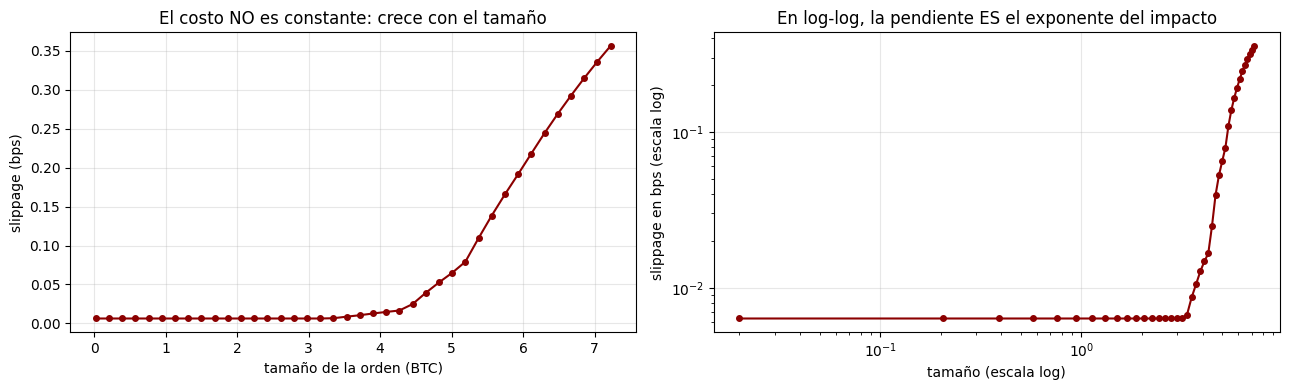


Pendiente estimada sobre ESTE libro real: 0.85



In [ ]:

tamanos = np.linspace(0.02, libro["ask_size"].sum() * 0.98, 40)
resultados = [(t, caminar_el_libro(libro, t)) for t in tamanos]
resultados = [(t, r["slippage_bps"]) for t, r in resultados if r is not None]
qs = np.array([x[0] for x in resultados])
sl = np.array([x[1] for x in resultados])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(qs, sl, "o-", ms=4, color="darkred")
ax[0].set_xlabel("tamaño de la orden (BTC)")
ax[0].set_ylabel("slippage (bps)")
ax[0].set_title("El costo NO es constante: crece con el tamaño")

mask = sl > 0
ax[1].loglog(qs[mask], sl[mask], "o-", ms=4, color="darkred")
ax[1].set_xlabel("tamaño (escala log)")
ax[1].set_ylabel("slippage en bps (escala log)")
ax[1].set_title("En log-log, la pendiente ES el exponente del impacto")
plt.tight_layout()
plt.show()

pendiente = np.polyfit(np.log(qs[mask]), np.log(sl[mask]), 1)[0]
print(f"""
Pendiente estimada sobre ESTE libro real: {pendiente:.2f}
""")

La literatura empírica (con muchísimos más datos que un solo snapshot) ubica
este exponente alrededor de 0.5 — la LEY DE RAÍZ CUADRADA del impacto de
mercado. Con un solo libro no vamos a recuperar ese 0.5 exacto (para eso hacen
falta muchos snapshots y muchas ejecuciones reales, no una foto), pero la
FORMA de la curva — cóncava, no lineal — ya es la lección.

### 🧠 La ley de raíz cuadrada, con su fórmula

El slippage no es mala suerte. **Es sistemático, y es modelable.** Ésa es una
de las regularidades empíricas más robustas que existen en finanzas —
replicada por Barra, Almgren, Bouchaud y las mesas de ejecución de
prácticamente todos los brokers del mundo.

Para una orden de tamaño $Q$ sobre un activo con volumen diario $V$ y
volatilidad $\sigma$:

$$\boxed{\;\frac{\Delta P}{P} \;\approx\; Y \cdot \sigma \cdot \sqrt{\frac{Q}{V}}\;}$$

con $Y$ una constante de orden 1. Qué dice cada término:

| Término | Qué significa | Consecuencia |
|---|---|---|
| $\sqrt{Q/V}$ | Tu tamaño **relativo al mercado** | Lo que importa no es cuánto operas, sino cuánto operas *comparado con el activo* |
| $\sigma$ | La volatilidad del activo | Operar activos volátiles cuesta más, aunque el spread sea igual |
| La raíz | El impacto es **cóncavo** | Duplicar el tamaño multiplica el costo por $\sqrt{2}\approx 1.41$, no por 2 |

### 📌 Por qué la concavidad es una buena y una mala noticia

**Buena:** duplicar el tamaño no duplica el costo total. Hay economías de
escala en la ejecución.

**Mala:** el costo **por unidad** sí sube, siempre, sin techo. No existe un
tamaño a partir del cual operar se vuelva gratis.

In [ ]:
# Estimemos la CAPACIDAD de una estrategia con la ley de raíz cuadrada
Y = 1.0          # constante de orden 1
COSTO_TOLERABLE = 0.0010     # 10 bps: el máximo que estamos dispuestos a pagar

print("CAPACIDAD MÁXIMA POR ACTIVO — ¿cuánto capital aguanta?\n")
print("Despejando Q de la ley de raíz cuadrada:")
print("    Q_max = V · (costo_tolerable / (Y·σ))²\n")
print(f"(tolerancia = {COSTO_TOLERABLE*1e4:.0f} bps por operación)\n")
def formato_dinero(x):
    """Formatea en M o K según magnitud, para que no se pierdan los chicos."""
    return f"${x/1e6:,.1f}M" if x >= 1e6 else f"${x/1e3:,.0f}K"


cap_filas = []
for tk, g in equities.groupby("ticker"):
    g = g.sort_values("date")
    V = g.tail(60)["dollar_volume"].mean()
    sigma_d = np.log(g["close"]).diff().std()       # volatilidad DIARIA
    Q_max = V * (COSTO_TOLERABLE / (Y * sigma_d)) ** 2
    cap_filas.append((tk, g["sector"].iloc[0], V, sigma_d * np.sqrt(252), Q_max))

cap_filas.sort(key=lambda r: -r[4])       # ordenado por capacidad

print(f"{'ticker':8} {'sector':12} {'$vol/día':>12} {'vol.anual':>10} {'capacidad':>13}")
print("─" * 60)
for tk, sec, V, vol_a, Q_max in cap_filas:
    print(f"{tk:8} {sec:12} ${V/1e6:>10,.0f}M {vol_a:>9.0%} {formato_dinero(Q_max):>13}")

print("""
LO QUE HAY QUE LEER AQUÍ:

1. La capacidad NO sigue el orden del dólar-volumen. Un activo muy negociado
   pero muy volátil puede aguantar MENOS capital que uno tranquilo con menos
   volumen. La σ está elevada al cuadrado en el denominador: la volatilidad
   castiga la capacidad más fuerte que lo que el volumen la ayuda.

2. Toda estrategia tiene un AUM MÁXIMO, y se puede ESTIMAR — no adivinar.
   Una estrategia que funciona con $100.000 puede ser imposible con $100M,
   y este cálculo te dice aproximadamente dónde está la frontera.

3. Esto es exactamente lo que hace que un fondo grande NO pueda hacer lo que
   hace un individuo. No es que no sepan: es que no les cabe.
""")

CAPACIDAD MÁXIMA POR ACTIVO — ¿cuánto capital aguanta?

Despejando Q de la ley de raíz cuadrada:
    Q_max = V · (costo_tolerable / (Y·σ))²

(tolerancia = 10 bps por operación)

ticker   sector           $vol/día  vol.anual     capacidad
────────────────────────────────────────────────────────────
AMD      Tecnología   $     8,119M       65%         $4.8M
MCD      Consumo      $       426M       17%         $3.6M
MS       Financiero   $       990M       35%         $2.1M
AMT      REIT         $       245M       24%         $1.0M
DTE      Utilities    $       162M       26%         $610K
SLB      Energía      $       415M       48%         $460K
BHP      Materiales   $       147M       35%         $304K
FLR      Industrial   $       129M       64%          $79K
GILT     Salud        $         8M       50%           $8K

LO QUE HAY QUE LEER AQUÍ:

1. La capacidad NO sigue el orden del dólar-volumen. Un activo muy negociado
   pero muy volátil puede aguantar MENOS capital que uno tranquil

---
# 6 · Liquidez ≠ volumen
**⏱ 20 minutos**

Ésta es la confusión más cara del retail. Y ahora la vemos con 9 acciones
reales, una por sector, con su dólar-volumen real de los últimos 60 días.

### Las cuatro dimensiones de la liquidez

| Dimensión | La pregunta que responde | Cómo se mide |
|---|---|---|
| **Amplitud** | ¿Cuánto cuesta entrar y salir? | El spread |
| **Profundidad** | ¿Cuánto puedo mover al mejor precio? | Tamaño en el tope del libro |
| **Resiliencia** | ¿Qué tan rápido se recupera el libro? | Tiempo de reversión tras un trade |
| **Inmediatez** | ¿Qué tan rápido puedo salir? | Tiempo hasta la ejecución |

### 🚨 Fíjate en lo que NO está en la tabla

**El volumen.**

Un activo puede tener volumen enorme y ser **ilíquido para ti**, si tu tamaño es
grande respecto a su profundidad. La liquidez no es una propiedad del activo:
es una relación entre **el activo y tu tamaño**.

In [ ]:
# DATOS LOCALES — reales, 9 sectores
filas = []
for tk, g in equities.groupby("ticker"):
    g = g.sort_values("date")
    sector = g["sector"].iloc[0]
    r = np.log(g["close"]).diff()
    ultimos_60 = g.tail(60)
    filas.append({
        "ticker": tk,
        "sector": sector,
        "precio": g["close"].iloc[-1],
        "volumen (acciones/día)": ultimos_60["volume"].mean(),
        "$ negociados/día": ultimos_60["dollar_volume"].mean(),
        "vol. anual": r.std() * np.sqrt(252),
    })

liquidez = pd.DataFrame(filas).set_index("ticker").sort_values(
    "$ negociados/día", ascending=False)
print(liquidez.assign(**{
    "volumen (acciones/día)": lambda x: (x["volumen (acciones/día)"] / 1e3).round(0).astype(int).astype(str) + "K",
    "$ negociados/día": lambda x: "$" + (x["$ negociados/día"] / 1e6).round(1).astype(str) + "M",
    "precio": lambda x: x["precio"].round(2),
    "vol. anual": lambda x: (x["vol. anual"] * 100).round(1).astype(str) + "%",
}).to_string())

print("""
Fíjate en el rango: de punta a punta hay un factor de casi 1.000x en dólares
negociados por día entre el sector más líquido y el menos líquido de esta
tabla — y ninguno de los 9 es un "penny stock". Todos son empresas reales,
cotizadas, con analistas cubriéndolas.
""")

            sector  precio volumen (acciones/día) $ negociados/día vol. anual
ticker                                                                       
AMD     Tecnología  511.26                 23260K         $8119.5M      65.2%
MS      Financiero  161.47                  5691K          $990.0M      34.8%
MCD        Consumo  307.80                  1405K          $426.4M      17.2%
SLB        Energía   38.15                 11622K          $414.6M      47.6%
AMT           REIT  187.14                  1369K          $245.3M      24.4%
DTE      Utilities  147.60                  1181K          $161.5M      25.8%
BHP     Materiales   60.36                  2596K          $147.1M      34.9%
FLR     Industrial   39.63                  2864K          $128.6M      63.9%
GILT         Salud   11.63                   637K            $8.2M      49.5%

Fíjate en el rango: de punta a punta hay un factor de casi 1.000x en dólares
negociados por día entre el sector más líquido y el menos líquid

### 🎯 Ejercicio guiado 1.2 — ¿cuánto puedo mover sin hacer ruido?

Una regla de oro de la industria: **no operes más del 1-3% del volumen diario**
de un activo, o tu propia orden moverá el precio en tu contra.

Calcula, para cada activo de la tabla, cuál es el tamaño máximo de posición
(en dólares) bajo esa regla. Y responde: **con una cuenta de $500.000, ¿en
cuáles de estos activos puedes operar cómodamente?**

In [ ]:
# ✍️ TU CÓDIGO AQUÍ

CAPACIDAD CON UNA CUENTA DE $500,000

            sector $ negociados/día máx al 1% máx al 3% ¿cabe mi cuenta?
ticker                                                                  
AMD     Tecnología         $8119.5M   $81195K  $243584K     ✅ sí, cómodo
MS      Financiero          $990.0M    $9900K   $29699K     ✅ sí, cómodo
MCD        Consumo          $426.4M    $4264K   $12793K     ✅ sí, cómodo
SLB        Energía          $414.6M    $4146K   $12437K     ✅ sí, cómodo
AMT           REIT          $245.3M    $2453K    $7359K     ✅ sí, cómodo
DTE      Utilities          $161.5M    $1615K    $4846K     ✅ sí, cómodo
BHP     Materiales          $147.1M    $1471K    $4412K     ✅ sí, cómodo
FLR     Industrial          $128.6M    $1286K    $3859K     ✅ sí, cómodo
GILT         Salud            $8.2M      $82K     $245K        ❌ no cabe


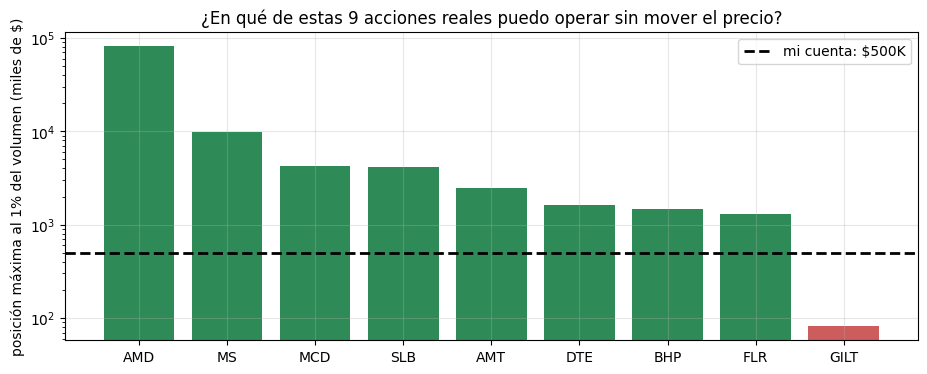


LA LECCIÓN:

Todos estos activos "se pueden comprar". Pero para TU tamaño, solo algunos son
realmente operables.

Y nota la asimetría cruel: los activos pequeños e ilíquidos son justo donde
suele haber más ineficiencias que explotar... y donde menos capital cabe.

Ésa es la razón por la que un fondo grande NO puede hacer lo que hace un trader
individual. Y también la razón por la que un trader individual tiene una
ventaja real que no debe desperdiciar copiando lo que hacen los fondos.



In [ ]:
# ✅ SOLUCIÓN
CAPITAL = 500_000

capacidad = liquidez[["sector", "$ negociados/día"]].copy()
capacidad["máx al 1%"] = capacidad["$ negociados/día"] * 0.01
capacidad["máx al 3%"] = capacidad["$ negociados/día"] * 0.03
capacidad["¿cabe mi cuenta?"] = np.where(
    capacidad["máx al 1%"] >= CAPITAL, "✅ sí, cómodo",
    np.where(capacidad["máx al 3%"] >= CAPITAL, "⚠️ justo", "❌ no cabe"))

print(f"CAPACIDAD CON UNA CUENTA DE ${CAPITAL:,}\n")
print(capacidad.assign(**{
    "$ negociados/día": lambda x: "$" + (x["$ negociados/día"] / 1e6).round(1).astype(str) + "M",
    "máx al 1%": lambda x: "$" + (x["máx al 1%"] / 1e3).round(0).astype(int).astype(str) + "K",
    "máx al 3%": lambda x: "$" + (x["máx al 3%"] / 1e3).round(0).astype(int).astype(str) + "K",
}).to_string())

plt.figure(figsize=(11, 4))
colores = ["seagreen" if v >= CAPITAL else "goldenrod" if v * 3 >= CAPITAL
           else "indianred" for v in capacidad["máx al 1%"]]
plt.bar(capacidad.index, capacidad["máx al 1%"] / 1e3, color=colores)
plt.axhline(CAPITAL / 1e3, color="k", ls="--", lw=2,
            label=f"mi cuenta: ${CAPITAL/1e3:.0f}K")
plt.ylabel("posición máxima al 1% del volumen (miles de $)")
plt.yscale("log")
plt.title("¿En qué de estas 9 acciones reales puedo operar sin mover el precio?")
plt.legend()
plt.show()

print("""
LA LECCIÓN:

Todos estos activos "se pueden comprar". Pero para TU tamaño, solo algunos son
realmente operables.

Y nota la asimetría cruel: los activos pequeños e ilíquidos son justo donde
suele haber más ineficiencias que explotar... y donde menos capital cabe.

Ésa es la razón por la que un fondo grande NO puede hacer lo que hace un trader
individual. Y también la razón por la que un trader individual tiene una
ventaja real que no debe desperdiciar copiando lo que hacen los fondos.
""")

---
# 7 · ¿Por qué existe el spread?
**⏱ 10 minutos**

Última pregunta de la sesión, y la más profunda.

El market maker está dispuesto a comprarte a 99.98 y venderte a 100.02. Se queda
con 4 centavos. **¿Por qué le dejamos cobrarlos?**

### Sus tres costos

**1. Costos de operación** — infraestructura, comisiones del exchange. Pequeño y
cada año menor.

**2. Riesgo de inventario** — al comprarte, se queda con una posición que no
quería. Tiene que financiarla y aguantar el riesgo hasta deshacerla.

**3. Selección adversa** — 👈 **éste es el importante.**

### La historia de la selección adversa

Imagina que pones un puesto de cambio de divisas. Compras dólares a 3.70 soles y
los vendes a 3.72.

Llegan dos tipos de clientes:

- **Turistas** — no saben nada, cambian cuando lo necesitan. Con ellos ganas.
- **Alguien que acaba de leer** que el BCR va a intervenir mañana. Ése solo te
  compra cuando *sabe* que el dólar va a subir. Con él **siempre pierdes**.

El problema: **no puedes distinguirlos al mirarlos.**

Así que solo tienes una defensa: **ampliar el spread**, de forma que lo que ganas
con los turistas cubra lo que pierdes con los informados.

**Dato real que conecta con esto:** el spread de BTC/USD que vimos en el
bloque 2 (≈0.01 bps) es tan angosto porque hay tantísimo flujo "turista" —
volumen minorista y de bots de arbitraje — que diluye el riesgo de toparse
con alguien informado. Un activo con menos flujo tiene, por definición, menos
turistas con quien diluir ese riesgo. La tabla de dólar-volumen del bloque 6
es la huella de eso: GILT negocia ~1.000 veces menos dólares al día que AMD,
y ésa es justamente la clase de activo donde, si pudiéramos ver su libro,
esperaríamos un spread mucho más ancho que el de BTC/USD.

### 🔴 El spread es el impuesto a la ignorancia

Éste es el corolario, y es el que hay que dejar grabado:

> **El spread que pagas es el subsidio que le das al mercado por no saber
> nada.**

El market maker no puede distinguir al informado del desinformado. Así que le
cobra a **todos** un seguro, y con lo que gana contra los turistas cubre lo que
pierde contra los informados. Es un impuesto plano sobre la ignorancia, y lo
pagas cada vez que cruzas el spread.

Si eres el turista, financias las pérdidas del market maker contra los
informados. Si tú *eres* el informado, el spread es un peaje pequeño comparado
con lo que vas a ganar.

Y de ahí sale la pregunta que vale la pena hacerse antes de cada operación:

### **En este trade, ¿soy el turista o el informado?**

Si no puedes responderla señalando algo concreto — un dato que tienes y otros
no, una restricción que te obliga a operar y a otros no, una paciencia que
otros no pueden permitirse — probablemente eres el turista.

*(Esta intuición tiene un modelo formal detrás: Glosten-Milgrom, 1985. No lo
necesitamos hoy, pero es la referencia si alguien quiere el aparato completo.)*

### ❌ Las cinco confusiones que hay que desarmar

Estas cinco frases suenan razonables y las vas a escuchar constantemente. Las
cinco son falsas, y ya tenemos con qué refutarlas:

| Lo que se dice | Por qué es falso |
|---|---|
| *"Volumen alto = líquido"* | La liquidez es relativa a **tu** tamaño. Lo vimos en la tabla del bloque 6 |
| *"El spread es el costo"* | El spread es el **piso** del costo, y solo para tamaños pequeños. Encima va el slippage |
| *"Las limit orders son gratis"* | Son una opción corta sin prima (bloque 4) |
| *"El mid es un precio"* | Nadie transa al mid. Es una construcción matemática |
| *"El slippage es mala suerte"* | Es **impacto de mercado**: sistemático, cóncavo y modelable (bloque 5) |

### 🙋 Preguntas difíciles que van a salir

**"¿Por qué existen los market makers si pierden contra los informados?"**
Porque ganan contra los desinformados, que son la mayoría del flujo. El negocio
es spread × volumen no informado, menos las pérdidas contra el flujo tóxico.

**"Si el impacto es raíz cuadrada, ¿por qué no partir la orden en infinitos
pedazos?"** Porque partirla te expone a **riesgo de precio** durante más
tiempo. Ejecutar rápido cuesta impacto; ejecutar lento cuesta riesgo. Existe un
óptimo, y es el tema de la sesión 2.

**"¿No es todo esto irrelevante si opero diario y con poco capital?"**
Es *menos* relevante, no irrelevante. Con capital chico tu impacto es casi
cero, pero **el spread sigue ahí**. Y en activos ilíquidos — small caps,
altcoins — el spread solo puede ser de 50 a 200 puntos básicos. Ahí es donde
muere la estrategia, no en el impacto.

---
# 📝 Cierre de la sesión

## Las seis cosas que te llevas

1. **El mid price es una ilusión óptica.** No existe "el precio": existen bid,
   ask y una cola de gente esperando.
2. **Hay tres spreads.** Cotizado (lo que ves), efectivo (lo que pagaste) y
   realizado (lo que el otro ganó). Y la descomposición:
   *efectivo = realizado + impacto permanente*.
3. **El slippage se mide contra el mid**, no contra el mejor ask. Cruzar el
   spread ya es un costo.
4. **Una orden limit es una put gratuita, sin prima.** Te ejecutan cuando le
   conviene al otro.
5. **El impacto es cóncavo:** $\Delta P/P \approx Y\sigma\sqrt{Q/V}$. De ahí
   sale que toda estrategia tiene un AUM máximo estimable.
6. **El spread es el impuesto a la ignorancia.** Es el precio de no saber.

## La próxima sesión

Le ponemos números al costo total y hacemos el cálculo que mata más estrategias
que ningún otro:

> Una estrategia que rota su cartera todos los días, con 10 puntos básicos de
> costo, necesita **25% de retorno bruto anual solo para empatar**.

Ahí también vamos a conocer el **estimador de Roll**, y con él aparece por
primera vez la razón por la que a veces SÍ vamos a usar un gemelo simulado
junto al dato real: para saber si un estimador recupera la verdad, primero
hay que conocer la verdad — y eso solo se puede garantizar generándola.

---

# 🎓 Ejercicios de la sesión

> **Importante:** estos ejercicios son la base de la **evaluación final del
> módulo**. La evaluación usará los mismos ejercicios con **variaciones** — otro
> activo, otro tamaño, otro escenario. Si los resuelves entendiendo (y no
> copiando), la evaluación te va a salir sola.

Resuélvelos en las celdas de abajo, sobre el libro y la cinta reales cargados
al inicio del notebook.

### Ejercicio 1 — El costo de tener prisa

Con el libro real de `data/order_book_real_xbtusd.parquet`:

**a)** Calcula el costo total, **en dólares**, de comprar 2 BTC con una
orden de mercado, comparado con el costo hipotético de comprarlos al mid.

**b)** ¿Cuánto de ese costo es por **cruzar el spread** y cuánto por **caminar
el libro**? Sepáralos.

> 💡 *Pista:* cruzar el spread cuesta medio spread por unidad. El resto es
> impacto por profundidad.

In [ ]:
# ✍️ TU RESPUESTA

### Ejercicio 2 — Compra y venta no cuestan igual

**a)** Calcula el slippage de comprar 3 BTC y el de vender 3 BTC sobre el
mismo libro.

**b)** ¿Son iguales? Explica **por qué** mirando el libro (revisa cuánta
profundidad hay en `bid_size` vs `ask_size`).

**c)** ¿Qué implica esto para una estrategia que entra y sale constantemente?

In [ ]:
# ✍️ TU RESPUESTA

### Ejercicio 3 — El activo importa más que la estrategia

Toma la acción de **mayor** $-volumen y la de **menor** $-volumen de la tabla
del bloque 6 (revisa `liquidez` ordenada).

**a)** Con el `vol. anual` de cada una, ordénalas de más a menos volátil.
¿Coincide el orden de volatilidad con el orden de liquidez? ¿Te sorprende?

**b)** Supón que tienes una estrategia con un edge bruto de **20 puntos
básicos por operación**, y que operas una vez al día. Con un costo redondo
estimado de 5 bps en la más líquida y 60 bps en la menos líquida, ¿cuál
sobrevive?

**c)** Escribe en dos frases qué le dirías a alguien que te muestra un
backtest rentable sobre la acción menos líquida de esta tabla.

In [ ]:
# ✍️ TU RESPUESTA

### Ejercicio 4 — Diseño de orden

Situación: tienes que comprar **8 BTC** contra el libro real cargado en este
notebook, cuyo lado ask visible suma en total (revisa `libro["ask_size"].sum()`).

**a)** ¿Qué pasa si mandas una orden de mercado por los 8 BTC completos?

**b)** Propón tres formas distintas de ejecutarla y di **qué riesgo asume cada
una**. Piensa en términos de: precio, tiempo, e información revelada al mercado.

**c)** ¿Cuál elegirías si supieras que el precio va a subir 5% en las próximas
dos horas? ¿Y si no tuvieras ni idea?

> Este ejercicio no tiene una respuesta única. Se evalúa el **razonamiento**.

In [ ]:
# ✍️ TU RESPUESTA (puedes responder en texto, en un comentario)

### Ejercicio 5 — 🌐 Opcional, con tu propio internet

Usando `traer_libro_en_vivo()` (bloque 3) contra otro par, por ejemplo
`ETHUSD` o `XRPUSD`:

**a)** Compara su spread en puntos básicos contra el de BTC/USD.

**b)** Calcula cuántas unidades puedes comprar antes de que el slippage
supere los **10 puntos básicos**, y compáralo contra BTC/USD.

**c)** ¿Cuál es la relación entre esas dos cifras y qué te dice sobre dónde
conviene operar?

> Si no tienes internet, compara en cambio dos acciones distintas de la
> tabla del bloque 6 usando el `vol. anual` como proxy grosero de liquidez.

In [ ]:
# ✍️ TU RESPUESTA

---

## 🔑 Para la próxima clase

Ven pensando en esto: **si cada operación cuesta dinero, ¿cuántas veces al año
te puedes permitir operar?**

La respuesta es menos veces de las que crees.